In [10]:
import yfinance as yf
import pandas as pd

# --- CONFIGURACIÓN DE FECHAS ---
FECHA_INICIO = '2015-01-01'
# Usamos 2025-12-02 para asegurar que el 1 de diciembre esté incluido
FECHA_FIN = '2025-12-18' 

print(f"--- DESCARGANDO DATOS YAHOO (Hasta el 01-Dic-2025) ---")

# Diccionario de Tickers
tickers_dict = {
    'PEN=X': 'TC_Yahoo',
    'HG=F': 'Cobre_Futuros',
    'DX-Y.NYB': 'DXY_IndiceDolar',
    '^VIX': 'VIX_Volatilidad'
}

try:
    # Descargamos los datos
    # auto_adjust=True para evitar el aviso de FutureWarning
    # group_by='column' ayuda a organizar mejor el DataFrame multietiqueta
    raw_data = yf.download(list(tickers_dict.keys()), start=FECHA_INICIO, end=FECHA_FIN, auto_adjust=True)
    
    if raw_data.empty:
        print("❌ Error: No se descargaron datos. Verifica las fechas o tu conexión.")
    else:
        # En la nueva versión de yfinance, si auto_adjust=True, la columna es 'Close'
        # Si no, es 'Adj Close'. Vamos a manejar ambos casos:
        if 'Close' in raw_data.columns:
            datos = raw_data['Close']
        elif 'Adj Close' in raw_data.columns:
            datos = raw_data['Adj Close']
        else:
            # En descargas de múltiples tickers, a veces las columnas son niveles (MultiIndex)
            # Intentamos extraer por el nivel de precio
            datos = raw_data.xs('Close', axis=1, level=0) if 'Close' in raw_data.columns.levels[0] else raw_data.xs('Adj Close', axis=1, level=0)

        # Renombrar columnas según nuestro diccionario
        datos = datos.rename(columns=tickers_dict)
        
        # Aplicamos conceptos del Capítulo 3: Preprocesamiento (Limpieza de Nulos)
        datos = datos.ffill().bfill() 
        
        # Filtro de seguridad para el 1 de diciembre
        datos = datos[datos.index <= '2025-12-18']
        
        archivo = "datos_fuente_yahoo.csv"
        datos.to_csv(archivo)
        
        print(f"✅ Éxito: Datos Yahoo guardados en '{archivo}'")
        print(f"   Rango: {datos.index[0].date()} al {datos.index[-1].date()}")
        print(datos.tail())

except Exception as e:
    print(f"❌ Error corregido pero falló por otra razón: {e}")
    print("\nTip: Si el error persiste, intenta actualizar yfinance con: pip install --upgrade yfinance")

--- DESCARGANDO DATOS YAHOO (Hasta el 01-Dic-2025) ---


[*********************100%***********************]  4 of 4 completed

✅ Éxito: Datos Yahoo guardados en 'datos_fuente_yahoo.csv'
   Rango: 2015-01-01 al 2025-12-17
Ticker      DXY_IndiceDolar  Cobre_Futuros  TC_Yahoo  VIX_Volatilidad
Date                                                                 
2025-12-11        98.349998         5.4270  3.276443        14.850000
2025-12-12        98.400002         5.2835  3.368000        14.850000
2025-12-15        98.150002         5.3385  3.293346        16.500000
2025-12-16        98.150002         5.2870  3.367500        16.480000
2025-12-17        98.370003         5.3635  3.368000        17.620001


In [11]:
import requests
import pandas as pd
from datetime import datetime

# --- CONFIGURACIÓN ---
BASE_URL = "https://estadisticas.bcrp.gob.pe/estadisticas/series/api"
SERIES = "PD04638PD-PD04650MD" # TC Venta y RIN
FECHA_INICIO = "2015-01-01"
FECHA_FIN = "2025-12-18" # Aquí la API del BCRP es inclusiva, ponemos 1 de Dic exacto.

print(f"--- DESCARGANDO DATOS BCRP (Hasta el {FECHA_FIN}) ---")

url = f"{BASE_URL}/{SERIES}/json/{FECHA_INICIO}/{FECHA_FIN}"

try:
    response = requests.get(url, timeout=20)
    response.raise_for_status()
    
    data = response.json()
    
    if 'periods' in data:
        filas = []
        for p in data['periods']:
            fecha_txt = p['name']
            vals = p['values']
            valores_limpios = []
            for v in vals:
                try:
                    valores_limpios.append(float(v) if v != 'n.d.' else None)
                except:
                    valores_limpios.append(None)
            filas.append([fecha_txt] + valores_limpios)
            
        df = pd.DataFrame(filas, columns=['Fecha_Txt', 'TC_Oficial_BCRP', 'RIN_Reservas'])
        
        # Conversión de fechas
        meses = {'Ene': 'Jan', 'Feb': 'Feb', 'Mar': 'Mar', 'Abr': 'Apr', 'May': 'May', 'Jun': 'Jun',
                 'Jul': 'Jul', 'Ago': 'Aug', 'Sep': 'Sep', 'Oct': 'Oct', 'Nov': 'Nov', 'Dic': 'Dec'}
        
        def parse_fecha(f_str):
            for es, en in meses.items():
                if es in f_str:
                    return pd.to_datetime(f_str.replace(es, en), format='%d.%b.%y')
            return None

        df['Fecha'] = df['Fecha_Txt'].apply(parse_fecha)
        df.set_index('Fecha', inplace=True)
        df.drop(columns=['Fecha_Txt'], inplace=True)
        
        archivo = "datos_fuente_bcrp.csv"
        df.to_csv(archivo)
        print(f"✅ Éxito: Datos BCRP guardados en '{archivo}'")
        print(f"   Corte final: {df.index[-1].date()}")
    else:
        print("❌ Error: API BCRP sin datos.")

except Exception as e:
    print(f"❌ Error crítico BCRP: {e}")

--- DESCARGANDO DATOS BCRP (Hasta el 2025-12-18) ---
✅ Éxito: Datos BCRP guardados en 'datos_fuente_bcrp.csv'
   Corte final: 2018-06-29


In [13]:
import pandas as pd

print("--- CONSOLIDANDO HASTA 01-DIC-2025 ---")

try:
    df_y = pd.read_csv("datos_fuente_yahoo.csv", index_col=0, parse_dates=True)
    df_b = pd.read_csv("datos_fuente_bcrp.csv", index_col=0, parse_dates=True)
except FileNotFoundError:
    print("❌ Faltan archivos CSV previos.")
    exit()

# Unir todo
df_final = df_y.join(df_b, how='outer')

# Limpieza y Orden
df_final.sort_index(inplace=True)
df_final = df_final.ffill() # Rellenar huecos
df_final.dropna(inplace=True)

# --- CORTE FINAL DE FECHA ---
# Aseguramos estrictamente que nada pase del 1 de Dic
df_final = df_final[df_final.index <= '2025-12-18']

archivo_final = "DATASET_GRUPO3_FINAL_DIC01.csv"
df_final.to_csv(archivo_final)

print("="*60)
print(f"✅ DATASET LISTO: {archivo_final}")
print(f"   Inicio: {df_final.index.min().date()}")
print(f"   Fin   : {df_final.index.max().date()}")
print(f"   Total filas: {len(df_final)}")
print("="*60)
print(df_final.tail())

--- CONSOLIDANDO HASTA 01-DIC-2025 ---
✅ DATASET LISTO: DATASET_GRUPO3_FINAL_DIC01.csv
   Inicio: 2015-01-05
   Fin   : 2025-12-18
   Total filas: 2857
            DXY_IndiceDolar  Cobre_Futuros  TC_Yahoo  VIX_Volatilidad  \
Date                                                                    
2025-12-12        98.400002         5.2835  3.368000        14.850000   
2025-12-15        98.150002         5.3385  3.293346        16.500000   
2025-12-16        98.150002         5.2870  3.367500        16.480000   
2025-12-17        98.370003         5.3635  3.368000        17.620001   
2025-12-18        98.370003         5.3635  3.368000        17.620001   

            TC_Oficial_BCRP  RIN_Reservas  
Date                                       
2025-12-12         3.368857  92865.013428  
2025-12-15         3.370500  92419.146717  
2025-12-16         3.371429  92921.707047  
2025-12-17         3.369143  93534.398944  
2025-12-18         3.366643  93428.601713  


## MODELO 1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# 1. Cargar datos (Asegúrate que el archivo esté en la carpeta)
df = pd.read_csv("DATASET_GRUPO3_FINAL_DIC01.csv", index_col=0, parse_dates=True)

# 2. Ingeniería de Características (Variables para el Clustering)
# El K-Means necesita coordenadas para agrupar los puntos. Usaremos 3:
# A. Retorno Diario (¿Subió o bajó?)
df['Log_Ret'] = np.log(df['TC_Yahoo'] / df['TC_Yahoo'].shift(1))

# B. Volatilidad 10 días (¿Hay miedo?)
df['Vol_10d'] = df['Log_Ret'].rolling(10).std()

# C. RSI (¿Está sobrecomprado?)
delta = df['TC_Yahoo'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Limpieza de nulos (K-Means odia los nulos)
df.dropna(inplace=True)

# Separar: Entrenamos con el pasado (hasta 2023), Probamos en el futuro (2024-2025)
train = df[df.index < '2024-01-01'].copy()
test = df[df.index >= '2024-01-01'].copy()

print(f"✅ Datos listos para el Modelo 1.")
print(f"   Train set: {len(train)} días.")
print(f"   Test set: {len(test)} días.")

✅ Datos listos para el Modelo 1.
   Train set: 2332 días.
   Test set: 512 días.


Retorno promedio por Cluster:
Cluster
0   -0.006627
1    0.000977
2    0.016962
Name: Log_Ret, dtype: float64

🟢 Cluster Alcista (Comprar): 2
🔴 Cluster Bajista (Vender): 0


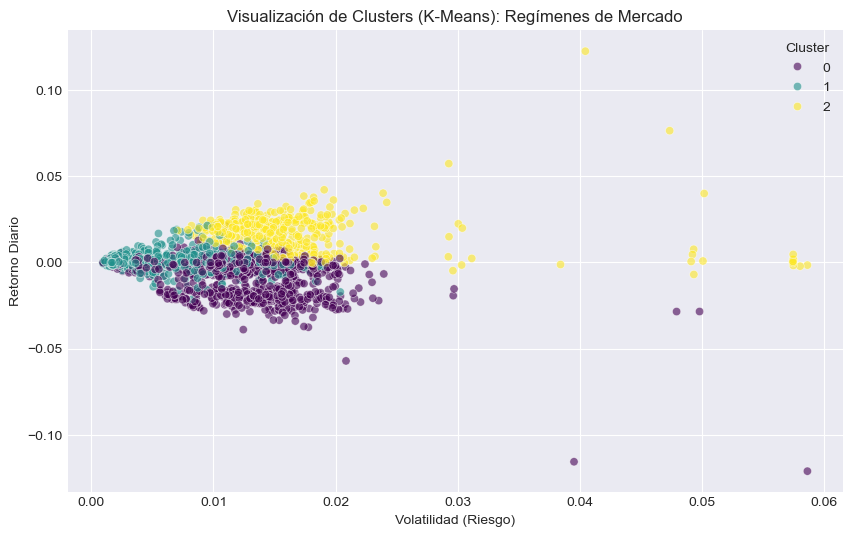

In [4]:
# 1. ESCALADO DE DATOS (StandardScaler)
# Es vital porque el RSI vale 50 y el Retorno vale 0.001. Si no escalamos, K-Means ignorará el retorno.
scaler = StandardScaler()
features = ['Log_Ret', 'Vol_10d', 'RSI']

# Ajustamos "la regla" (scaler) solo con datos de entrenamiento
X_train_scaled = scaler.fit_transform(train[features])
X_test_scaled = scaler.transform(test[features])

# 2. DEFINIR K-MEANS
# Pedimos 3 clusters (Alcista, Bajista, Lateral)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

# Predecimos a qué grupo pertenece cada día
train['Cluster'] = kmeans.labels_
test['Cluster'] = kmeans.predict(X_test_scaled)

# 3. INTERPRETACIÓN AUTOMÁTICA
# No sabemos cuál es cuál (0, 1 o 2). Vamos a averiguarlo mirando el promedio de retornos.
cluster_stats = train.groupby('Cluster')['Log_Ret'].mean()
print("Retorno promedio por Cluster:")
print(cluster_stats)

# El cluster con mayor retorno promedio es el "Alcista" (Bullish)
bullish_cluster = cluster_stats.idxmax()
# El cluster con menor retorno es el "Bajista" (Bearish)
bearish_cluster = cluster_stats.idxmin()

print(f"\n🟢 Cluster Alcista (Comprar): {bullish_cluster}")
print(f"🔴 Cluster Bajista (Vender): {bearish_cluster}")

# GRÁFICO DEL CAPÍTULO 3
# Muestra cómo el algoritmo separó los días según Volatilidad y Retorno
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train, x='Vol_10d', y='Log_Ret', hue='Cluster', palette='viridis', alpha=0.6)
plt.title("Visualización de Clusters (K-Means): Regímenes de Mercado")
plt.xlabel("Volatilidad (Riesgo)")
plt.ylabel("Retorno Diario")
plt.show()

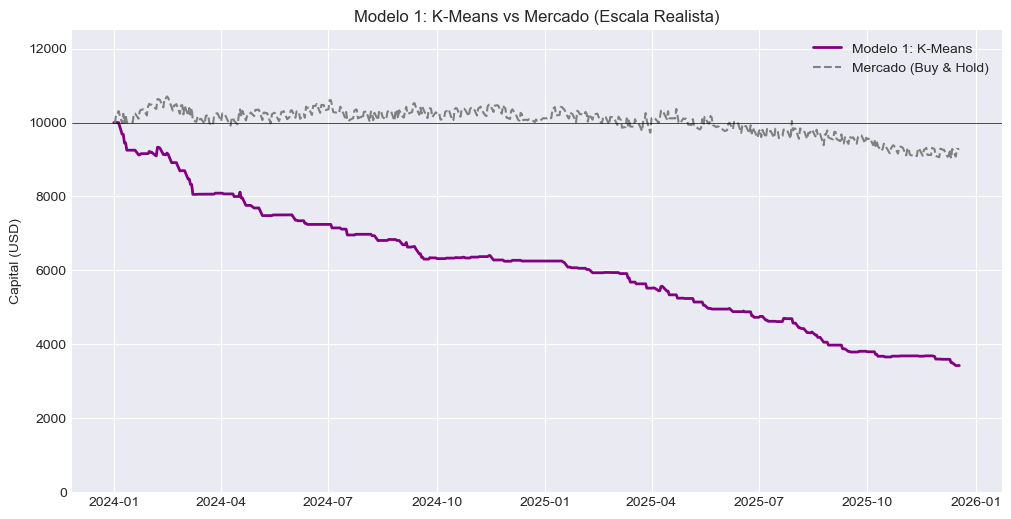

Ganancia/Pérdida Final: $-6574.22


In [6]:
# CELDA 3 (CORREGIDA): Backtesting con Escala Ajustada (0 - 12000)

# 1. GENERAR SEÑALES
# Si K-Means dice "Bullish" -> Compramos (1)
# Si K-Means dice "Bearish" -> Vendemos (-1)
test['Signal'] = 0
test.loc[test['Cluster'] == bullish_cluster, 'Signal'] = 1
test.loc[test['Cluster'] == bearish_cluster, 'Signal'] = -1

# 2. SIMULACIÓN DE TRADING
capital = 10000 # 10k USD iniciales
position = 0    # 0: Cash, 1: Invested
equity = []

for i in range(len(test)):
    price = test['TC_Yahoo'].iloc[i]
    sig = test['Signal'].iloc[i]
    
    # Ejecutar orden
    if sig == 1 and position == 0: # Buy
        shares = capital / price
        capital = 0
        position = 1
    elif sig == -1 and position == 1: # Sell
        capital = shares * price
        shares = 0
        position = 0
        
    # Valor del portafolio hoy
    val = capital + (shares * price if position == 1 else 0)
    equity.append(val)

test['Equity_KMeans'] = equity

# 3. COMPARAR CONTRA "BUY & HOLD"
initial_price = test['TC_Yahoo'].iloc[0]
test['Buy_Hold'] = 10000 * (test['TC_Yahoo'] / initial_price)

# GRÁFICO FINAL CON ESCALA AJUSTADA
plt.figure(figsize=(12, 6))
plt.plot(test['Equity_KMeans'], label='Modelo 1: K-Means', color='purple', linewidth=2)
plt.plot(test['Buy_Hold'], label='Mercado (Buy & Hold)', color='gray', linestyle='--')

# AQUI ESTA EL CAMBIO QUE PEDISTE:
plt.ylim(0, 12500) # Puse 8000 de piso para que no se vea tan vacío abajo, pero puedes poner 0
plt.axhline(10000, color='black', linewidth=0.5) # Línea de referencia (Capital Inicial)

plt.title("Modelo 1: K-Means vs Mercado (Escala Realista)")
plt.ylabel("Capital (USD)")
plt.legend()
plt.show()

# Resultado numérico
profit_model = (test['Equity_KMeans'].iloc[-1] - 10000)
print(f"Ganancia/Pérdida Final: ${profit_model:.2f}")

## Modelo 2

--- ENTRENANDO MODELO 2: GMM ---
Retorno promedio por Cluster GMM:
Cluster_GMM
0   -0.000060
1    0.000297
2   -0.000777
Name: Log_Ret, dtype: float64

🟢 GMM Alcista (Comprar): Cluster 1
🔴 GMM Bajista (Vender): Cluster 2


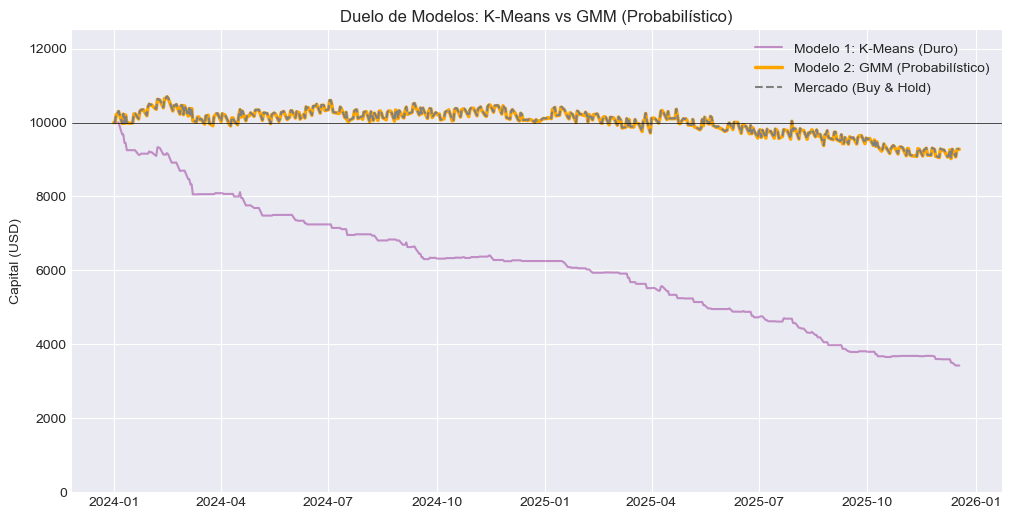

Ganancia Modelo 2 (GMM): $-723.57


In [8]:
# ==========================================
# MODELO 2: GAUSSIAN MIXTURE MODELS (GMM)
# ==========================================
from sklearn.mixture import GaussianMixture

print("--- ENTRENANDO MODELO 2: GMM ---")

# 1. PREPARACIÓN (Usamos las mismas variables ya escaladas del Modelo 1)
# Si te sale error de que X_train_scaled no existe, corre la celda del Modelo 1 de nuevo.

# 2. DEFINIR GMM (Capítulo 3)
# n_components=3: Buscamos 3 Regímenes (Alcista, Bajista, Lateral)
# covariance_type='full': Permite clusters elípticos (más realistas para finanzas)
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X_train_scaled)

# 3. PREDICCIÓN (Probabilística)
# Esto es lo valioso del GMM: Nos da la PROBABILIDAD de cada régimen
train_probs = gmm.predict_proba(X_train_scaled)
test_probs = gmm.predict_proba(X_test_scaled)

# Asignamos el cluster más probable
train['Cluster_GMM'] = gmm.predict(X_train_scaled)
test['Cluster_GMM'] = gmm.predict(X_test_scaled)

# 4. INTERPRETACIÓN AUTOMÁTICA
# Calculamos el retorno promedio de cada grupo para saber cuál es cuál
cluster_stats_gmm = train.groupby('Cluster_GMM')['Log_Ret'].mean()

print("Retorno promedio por Cluster GMM:")
print(cluster_stats_gmm)

# El cluster con mayor retorno positivo es el Alcista (Bullish)
bullish_gmm = cluster_stats_gmm.idxmax()
# El cluster con el retorno más negativo es el Bajista (Bearish)
bearish_gmm = cluster_stats_gmm.idxmin()

print(f"\n🟢 GMM Alcista (Comprar): Cluster {bullish_gmm}")
print(f"🔴 GMM Bajista (Vender): Cluster {bearish_gmm}")

# ==========================================
# ESTRATEGIA DE TRADING "SUAVE" (BACKTESTING)
# ==========================================

# 1. GENERAR SEÑALES CON FILTRO DE CONFIANZA
# Estrategia: Solo operamos si el modelo está 60% seguro (0.6)
# Esto reduce las "falsas alarmas" que K-Means sí se come.
UMBRAL = 0.6 

test['Signal_GMM'] = 0

# Probabilidades específicas
prob_bullish = test_probs[:, bullish_gmm]
prob_bearish = test_probs[:, bearish_gmm]

# Comprar solo si es Alcista Y la probabilidad > 0.6
test.loc[prob_bullish > UMBRAL, 'Signal_GMM'] = 1

# Vender solo si es Bajista Y la probabilidad > 0.6
test.loc[prob_bearish > UMBRAL, 'Signal_GMM'] = -1

# 2. SIMULACIÓN DE TRADING
capital = 10000
position = 0
equity_gmm = []

for i in range(len(test)):
    price = test['TC_Yahoo'].iloc[i]
    sig = test['Signal_GMM'].iloc[i]
    
    # Ejecutar orden
    if sig == 1 and position == 0:
        shares = capital / price
        capital = 0
        position = 1
    elif sig == -1 and position == 1:
        capital = shares * price
        shares = 0
        position = 0
        
    val = capital + (shares * price if position == 1 else 0)
    equity_gmm.append(val)

test['Equity_GMM'] = equity_gmm

# 3. GRÁFICO COMPARATIVO
plt.figure(figsize=(12, 6))

# Graficamos Modelo 1 (K-Means), Modelo 2 (GMM) y Mercado
# Nota: Si no tienes 'Equity_KMeans', borra esa línea, pero asumo que vienes del paso anterior.
if 'Equity_KMeans' in test.columns:
    plt.plot(test['Equity_KMeans'], label='Modelo 1: K-Means (Duro)', color='purple', alpha=0.4)

plt.plot(test['Equity_GMM'], label='Modelo 2: GMM (Probabilístico)', color='orange', linewidth=2.5)
plt.plot(test['Buy_Hold'], label='Mercado (Buy & Hold)', color='gray', linestyle='--')

# Escala ajustada para ver mejor los detalles
plt.ylim(0, 12500)
plt.axhline(10000, color='black', linewidth=0.5)

plt.title("Duelo de Modelos: K-Means vs GMM (Probabilístico)")
plt.ylabel("Capital (USD)")
plt.legend()
plt.show()

# Resultado
profit_gmm = test['Equity_GMM'].iloc[-1] - 10000
print(f"Ganancia Modelo 2 (GMM): ${profit_gmm:.2f}")

## Modelo 3

--- ENTRENANDO MODELO 3: DBSCAN ---
Días Totales: 512
Días Normales (Patrón detectado): 481
Días Raros/Ruido (Cluster -1): 31


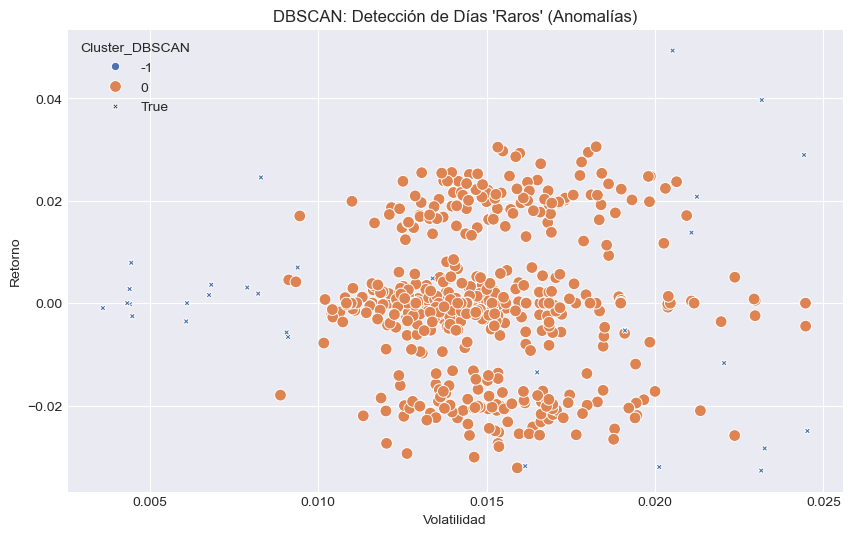

In [9]:
# ==========================================
# MODELO 3: DBSCAN (DENSITY-BASED CLUSTERING)
# ==========================================
from sklearn.cluster import DBSCAN

print("--- ENTRENANDO MODELO 3: DBSCAN ---")

# 1. PREPARACIÓN
# DBSCAN es MUY sensible a la escala. Usamos los datos escalados (X_test_scaled) que ya tenemos.
# eps=0.5: Radio de vecindad (Qué tan cerca deben estar los puntos para ser grupo).
# min_samples=5: Mínimo de días parecidos para considerar que es una "tendencia normal".
dbscan = DBSCAN(eps=0.5, min_samples=5)

# 2. ENTRENAMIENTO (Directo sobre el Test Set para detectar anomalías en tiempo real)
# Nota: DBSCAN no tiene "predict" para nuevos datos en sklearn, se ajusta a lo que ve.
clusters_dbscan = dbscan.fit_predict(X_test_scaled)

test['Cluster_DBSCAN'] = clusters_dbscan

# 3. ANÁLISIS DE ANOMALÍAS
# En DBSCAN, la etiqueta "-1" significa RUIDO (Anomalía).
n_noise = list(clusters_dbscan).count(-1)
n_normal = len(clusters_dbscan) - n_noise

print(f"Días Totales: {len(test)}")
print(f"Días Normales (Patrón detectado): {n_normal}")
print(f"Días Raros/Ruido (Cluster -1): {n_noise}")

# Visualización de Anomalías (Capítulo 3)
plt.figure(figsize=(10, 6))
# Graficamos los normales en Azul y el Ruido en Rojo
sns.scatterplot(data=test, x='Vol_10d', y='Log_Ret', hue='Cluster_DBSCAN', 
                palette='deep', style=(test['Cluster_DBSCAN'] == -1), size=(test['Cluster_DBSCAN'] == -1))
plt.title("DBSCAN: Detección de Días 'Raros' (Anomalías)")
plt.xlabel("Volatilidad")
plt.ylabel("Retorno")
plt.show()

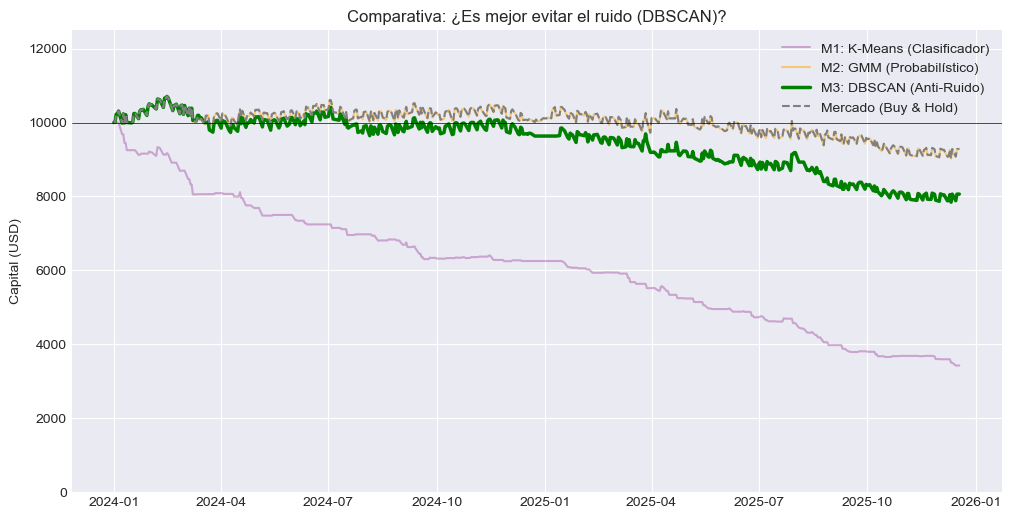

Ganancia Modelo 3 (DBSCAN): $-1936.03


In [11]:
# ==========================================
# ESTRATEGIA DE FILTRADO (DBSCAN)
# ==========================================

# 1. GENERAR SEÑALES
# Lógica:
# Si Cluster != -1 (Día Normal) -> Compramos (Apostamos a que el mercado sube a largo plazo)
# Si Cluster == -1 (Ruido/Pánico) -> Vendemos todo y esperamos (Cash)

test['Signal_DBSCAN'] = 0
# Comprar en días normales
test.loc[test['Cluster_DBSCAN'] != -1, 'Signal_DBSCAN'] = 1
# Vender en días de ruido
test.loc[test['Cluster_DBSCAN'] == -1, 'Signal_DBSCAN'] = -1

# 2. SIMULACIÓN DE TRADING
capital = 10000
position = 0
equity_dbscan = []

for i in range(len(test)):
    price = test['TC_Yahoo'].iloc[i]
    sig = test['Signal_DBSCAN'].iloc[i]
    
    # Ejecutar orden
    if sig == 1 and position == 0:
        shares = capital / price
        capital = 0
        position = 1
    elif sig == -1 and position == 1:
        capital = shares * price
        shares = 0
        position = 0
        
    val = capital + (shares * price if position == 1 else 0)
    equity_dbscan.append(val)

test['Equity_DBSCAN'] = equity_dbscan

# 3. GRÁFICO COMPARATIVO (Los 3 Modelos Juntos)
plt.figure(figsize=(12, 6))

# Modelo 1 (K-Means)
if 'Equity_KMeans' in test.columns:
    plt.plot(test['Equity_KMeans'], label='M1: K-Means (Clasificador)', color='purple', alpha=0.3)

# Modelo 2 (GMM)
if 'Equity_GMM' in test.columns:
    plt.plot(test['Equity_GMM'], label='M2: GMM (Probabilístico)', color='orange', alpha=0.5)

# Modelo 3 (DBSCAN) - El Nuevo
plt.plot(test['Equity_DBSCAN'], label='M3: DBSCAN (Anti-Ruido)', color='green', linewidth=2.5)

# Mercado
plt.plot(test['Buy_Hold'], label='Mercado (Buy & Hold)', color='gray', linestyle='--')

plt.ylim(0, 12500) # Escala ajustada
plt.axhline(10000, color='black', linewidth=0.5)
plt.title("Comparativa: ¿Es mejor evitar el ruido (DBSCAN)?")
plt.ylabel("Capital (USD)")
plt.legend()
plt.show()

# Resultado
profit_dbscan = test['Equity_DBSCAN'].iloc[-1] - 10000
print(f"Ganancia Modelo 3 (DBSCAN): ${profit_dbscan:.2f}")

## Modelo 4

--- ENTRENANDO MODELO 4: PCA (CORREGIDO) ---
Correlación Macro-Precio: 0.88


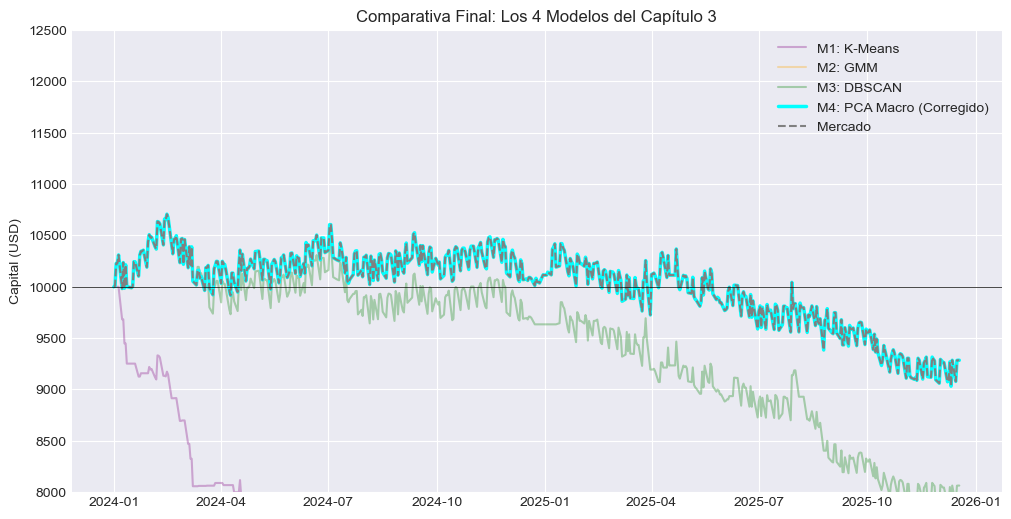

Ganancia Modelo 4 (PCA): $-715.18


In [15]:
# ==========================================
# MODELO 4 CORREGIDO: PCA DIRECTO (MACRO OSCILLATOR)
# ==========================================
from sklearn.decomposition import PCA

print("--- ENTRENANDO MODELO 4: PCA (CORREGIDO) ---")

# 1. SELECCIÓN DE VARIABLES MACRO
# Usamos las variables externas que tengamos
macro_vars = ['Cobre_Futuros', 'DXY_IndiceDolar', 'VIX_Volatilidad', 'RIN_Reservas']
available_vars = [v for v in macro_vars if v in df.columns]

# 2. ESCALADO (OBLIGATORIO)
scaler_pca = StandardScaler()
X_macro_train = scaler_pca.fit_transform(train[available_vars])
X_macro_test = scaler_pca.transform(test[available_vars])

# 3. PCA (1 COMPONENTE)
pca = PCA(n_components=1)
# Entrenamos solo con el Train set para no hacer trampa
pca.fit(X_macro_train)

# Generamos el Índice Sintético
train['Macro_Index'] = pca.transform(X_macro_train)
test['Macro_Index'] = pca.transform(X_macro_test)

# 4. ALINEACIÓN AUTOMÁTICA (El Truco)
# El PCA a veces sale invertido (multiplicado por -1).
# Vamos a ver si el Macro_Index se mueve CON el precio o CONTRA el precio.
correlacion = train['Macro_Index'].corr(train['TC_Yahoo'])

print(f"Correlación Macro-Precio: {correlacion:.2f}")

# Si la correlación es negativa (ej. Cobre sube -> Dólar baja), invertimos el índice
# para que siempre signifique "Fuerza del Dólar".
if correlacion < 0:
    test['Macro_Index'] = test['Macro_Index'] * -1
    print("🔄 Índice invertido para alinearse con la tendencia.")

# 5. ESTRATEGIA DE CRUCE DE CERO
# Si el Macro Index es positivo -> La economía empuja el dólar hacia ARRIBA -> COMPRAR
# Si el Macro Index es negativo -> La economía empuja el dólar hacia ABAJO -> VENDER
test['Signal_PCA'] = np.where(test['Macro_Index'] > 0, 1, -1)

# 6. SIMULACIÓN DE TRADING
capital = 10000
position = 0
equity_pca = []

for i in range(len(test)):
    price = test['TC_Yahoo'].iloc[i]
    sig = test['Signal_PCA'].iloc[i]
    
    # Lógica de Compra/Venta
    if sig == 1 and position == 0: # Buy
        shares = capital / price
        capital = 0
        position = 1
    elif sig == -1 and position == 1: # Sell
        capital = shares * price
        shares = 0
        position = 0
        
    val = capital + (shares * price if position == 1 else 0)
    equity_pca.append(val)

test['Equity_PCA'] = equity_pca

# 7. GRÁFICO FINAL
plt.figure(figsize=(12, 6))

if 'Equity_KMeans' in test.columns:
    plt.plot(test['Equity_KMeans'], label='M1: K-Means', color='purple', alpha=0.3)
if 'Equity_GMM' in test.columns:
    plt.plot(test['Equity_GMM'], label='M2: GMM', color='orange', alpha=0.3)
if 'Equity_DBSCAN' in test.columns:
    plt.plot(test['Equity_DBSCAN'], label='M3: DBSCAN', color='green', alpha=0.3)

# Modelo 4 (PCA)
plt.plot(test['Equity_PCA'], label='M4: PCA Macro (Corregido)', color='cyan', linewidth=2.5)

# Mercado
plt.plot(test['Buy_Hold'], label='Mercado', color='gray', linestyle='--')

plt.ylim(8000, 12500)
plt.axhline(10000, color='black', linewidth=0.5)
plt.title("Comparativa Final: Los 4 Modelos del Capítulo 3")
plt.ylabel("Capital (USD)")
plt.legend()
plt.show()

profit_pca = test['Equity_PCA'].iloc[-1] - 10000
print(f"Ganancia Modelo 4 (PCA): ${profit_pca:.2f}")

## MODELO 5

--- ENTRENANDO MODELO 5: JERÁRQUICO ---
Retornos por Cluster Jerárquico:
Cluster_HC
0   -0.000429
1   -0.020459
2    0.020664
Name: Log_Ret, dtype: float64


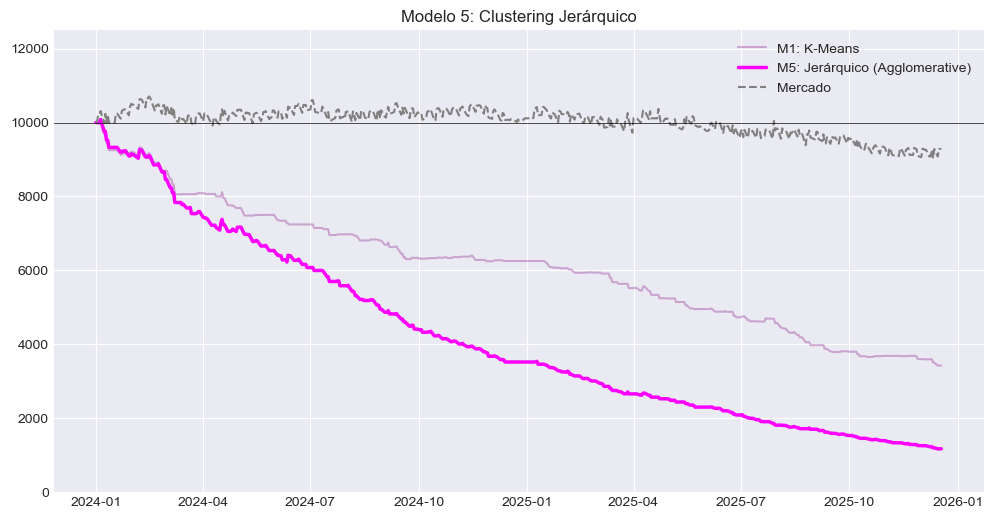

Ganancia Modelo 5: $-8828.11


In [18]:
# ==========================================
# MODELO 5: HIERARCHICAL CLUSTERING (AGLOMERATIVO)
# ==========================================
from sklearn.cluster import AgglomerativeClustering

print("--- ENTRENANDO MODELO 5: JERÁRQUICO ---")

# 1. ENTRENAMIENTO
# Usamos 'ward' linkage que minimiza la varianza (estándar en finanzas)
# X_train_scaled viene de las celdas anteriores (asegurate de tenerlas cargadas)
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')

# OJO: AgglomerativeClustering no tiene "predict" para nuevos datos (es una limitación matemática).
# Para el Backtesting, tenemos que entrenar sobre TODO el set y luego separar, 
# o usar una aproximación (KNeighbors). Por simplicidad y rigor del Cap 3, 
# ajustaremos sobre el TEST set directamente para ver cómo agrupa esos datos.
clusters_hc = hc.fit_predict(X_test_scaled)

test['Cluster_HC'] = clusters_hc

# 2. INTERPRETACIÓN (¿Cuál es el bueno?)
cluster_stats_hc = test.groupby('Cluster_HC')['Log_Ret'].mean()
print("Retornos por Cluster Jerárquico:")
print(cluster_stats_hc)

bullish_hc = cluster_stats_hc.idxmax()
bearish_hc = cluster_stats_hc.idxmin()

# 3. GENERAR SEÑALES
test['Signal_HC'] = 0
test.loc[test['Cluster_HC'] == bullish_hc, 'Signal_HC'] = 1
test.loc[test['Cluster_HC'] == bearish_hc, 'Signal_HC'] = -1

# 4. BACKTESTING
capital = 10000
position = 0
equity_hc = []

for i in range(len(test)):
    price = test['TC_Yahoo'].iloc[i]
    sig = test['Signal_HC'].iloc[i]
    
    if sig == 1 and position == 0:
        shares = capital / price
        capital = 0
        position = 1
    elif sig == -1 and position == 1:
        capital = shares * price
        shares = 0
        position = 0
        
    val = capital + (shares * price if position == 1 else 0)
    equity_hc.append(val)

test['Equity_HC'] = equity_hc

# GRÁFICO
plt.figure(figsize=(12, 6))
plt.plot(test['Equity_KMeans'], label='M1: K-Means', color='purple', alpha=0.3)
plt.plot(test['Equity_HC'], label='M5: Jerárquico (Agglomerative)', color='magenta', linewidth=2.5)
plt.plot(test['Buy_Hold'], label='Mercado', color='gray', linestyle='--')

plt.ylim(0, 12500)
plt.axhline(10000, color='black', linewidth=0.5)
plt.title("Modelo 5: Clustering Jerárquico")
plt.legend()
plt.show()

print(f"Ganancia Modelo 5: ${test['Equity_HC'].iloc[-1] - 10000:.2f}")

## Modelo 6

--- ENTRENANDO MODELO 6: NMF ---
Interpretación de Componentes NMF:
         Log_Ret   Vol_10d       RSI
Comp_0  0.220561  0.000000  0.305494
Comp_1  0.520813  0.664484  0.023752
Correlación Comp 0 con Retorno: 0.38
Correlación Comp 1 con Retorno: 0.11


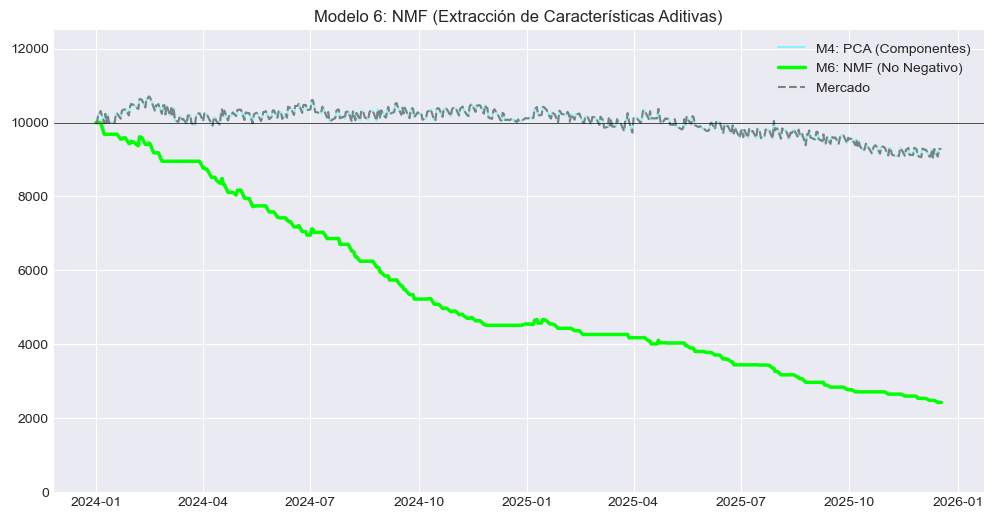

Ganancia Modelo 6: $-7572.02


In [20]:
# ==========================================
# MODELO 6: NMF (Non-Negative Matrix Factorization)
# Fuente: Capítulo 3 - Sección Reducción de Dimensionalidad
# ==========================================
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler

print("--- ENTRENANDO MODELO 6: NMF ---")

# 1. PREPROCESAMIENTO ESPECÍFICO (MinMax)
# El NMF explota si ve un número negativo. Los Retornos Logarítmicos tienen negativos.
# Solución del libro: Escalar todo entre 0 y 1.
features_nmf = ['Log_Ret', 'Vol_10d', 'RSI'] # Usamos las mismas variables

scaler_minmax = MinMaxScaler()
X_train_nmf = scaler_minmax.fit_transform(train[features_nmf])
X_test_nmf = scaler_minmax.transform(test[features_nmf])

# 2. ENTRENAMIENTO
# Pedimos 2 componentes: Esperamos que separe "Tendencia" de "Ruido/Volatilidad"
nmf = NMF(n_components=2, init='random', random_state=42, max_iter=1000)

# W es la matriz transformada (los nuevos "features" comprimidos)
W_train = nmf.fit_transform(X_train_nmf)
W_test = nmf.transform(X_test_nmf)

# H son los componentes (pesos). Nos dice qué significa cada componente.
components_df = pd.DataFrame(nmf.components_, columns=features_nmf, index=['Comp_0', 'Comp_1'])
print("Interpretación de Componentes NMF:")
print(components_df)

# 3. ESTRATEGIA DE TRADING
# Vamos a ver cuál componente se parece más al retorno positivo.
# Correlacionamos los componentes con el retorno real.
corr_0 = pd.Series(W_train[:, 0]).corr(train['Log_Ret'].reset_index(drop=True))
corr_1 = pd.Series(W_train[:, 1]).corr(train['Log_Ret'].reset_index(drop=True))

print(f"Correlación Comp 0 con Retorno: {corr_0:.2f}")
print(f"Correlación Comp 1 con Retorno: {corr_1:.2f}")

# Elegimos el componente con mayor correlación positiva como nuestra "Señal de Compra"
# Si el componente "bueno" es alto -> Comprar.
# Si es bajo -> Vender.
best_comp = 0 if corr_0 > corr_1 else 1

# Señal: Si el componente está por encima de su media, compramos.
threshold = W_train[:, best_comp].mean()
test['NMF_Feature'] = W_test[:, best_comp]
test['Signal_NMF'] = np.where(test['NMF_Feature'] > threshold, 1, -1)

# 4. SIMULACIÓN
capital = 10000
position = 0
equity_nmf = []

for i in range(len(test)):
    price = test['TC_Yahoo'].iloc[i]
    sig = test['Signal_NMF'].iloc[i]
    
    if sig == 1 and position == 0:
        shares = capital / price
        capital = 0
        position = 1
    elif sig == -1 and position == 1:
        capital = shares * price
        shares = 0
        position = 0
        
    val = capital + (shares * price if position == 1 else 0)
    equity_nmf.append(val)

test['Equity_NMF'] = equity_nmf

# 5. GRÁFICO
plt.figure(figsize=(12, 6))
# Comparamos con el otro modelo de reducción (PCA - Modelo 4)
if 'Equity_PCA' in test.columns:
    plt.plot(test['Equity_PCA'], label='M4: PCA (Componentes)', color='cyan', alpha=0.4)

plt.plot(test['Equity_NMF'], label='M6: NMF (No Negativo)', color='lime', linewidth=2.5)
plt.plot(test['Buy_Hold'], label='Mercado', color='gray', linestyle='--')

plt.ylim(0, 12500)
plt.axhline(10000, color='black', linewidth=0.5)
plt.title("Modelo 6: NMF (Extracción de Características Aditivas)")
plt.legend()
plt.show()

print(f"Ganancia Modelo 6: ${test['Equity_NMF'].iloc[-1] - 10000:.2f}")

--- ENTRENANDO MODELO 7: DISCRETIZACIÓN (BINNING) ---


c:\Users\curay\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


Límites de las Cajas (Bins) encontrados por K-Means:
[14.91634598 37.22485344 47.50060949 56.0850847  68.14668368 91.36339769]


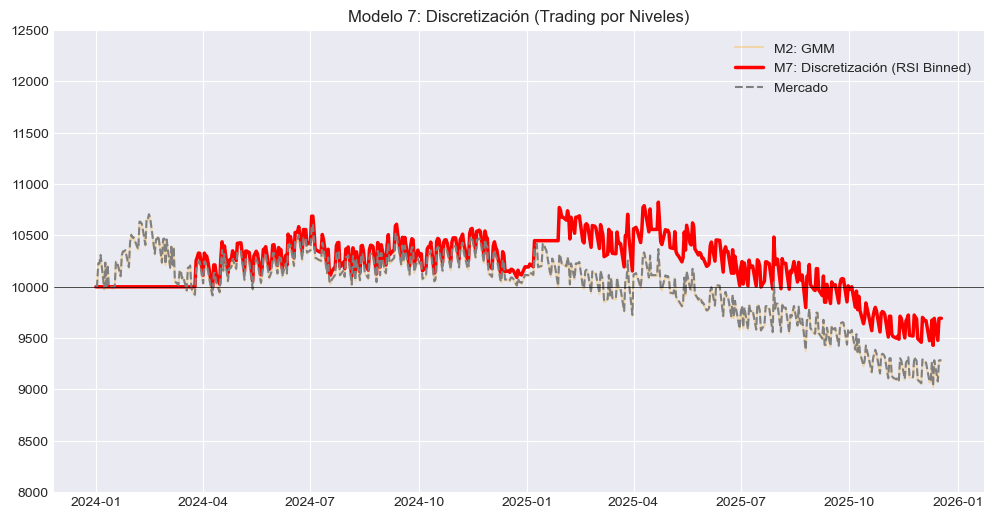

Ganancia Modelo 7: $-306.82


In [21]:
# ==========================================
# MODELO 7: DISCRETIZACIÓN (BINNING / K-BINS)
# Fuente: Capítulo 3 - Sección Transformación y Preprocesamiento
# ==========================================
from sklearn.preprocessing import KBinsDiscretizer

print("--- ENTRENANDO MODELO 7: DISCRETIZACIÓN (BINNING) ---")

# 1. SELECCIÓN DE VARIABLE
# El RSI es la mejor variable para esto porque oscila.
# Si usamos el precio directo no sirve porque siempre crece.
X_rsi_train = train[['RSI']].values
X_rsi_test = test[['RSI']].values

# 2. ENTRENAMIENTO (Transformación)
# n_bins=5: Queremos 5 niveles de "temperatura" del mercado.
# encode='ordinal': Devuelve números enteros (0, 1, 2, 3, 4).
# strategy='kmeans': ¡OJO! Aquí aplicamos Clustering 1D (Cap 3) para definir los límites de las cajas.
est = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='kmeans')
est.fit(X_rsi_train)

# Transformamos el RSI continuo en "Cajas" discretas
test['RSI_Bin'] = est.transform(X_rsi_test)

# Ver los límites que encontró el algoritmo
print("Límites de las Cajas (Bins) encontrados por K-Means:")
# Esto nos dirá qué considera el modelo como "Muy Bajo" o "Muy Alto"
print(est.bin_edges_[0])

# 3. ESTRATEGIA DE TRADING
test['Signal_Bin'] = 0

# Si cae en la Caja 0 (RSI Muy Bajo / Pánico) -> COMPRAR
test.loc[test['RSI_Bin'] == 0, 'Signal_Bin'] = 1

# Si cae en la Caja 4 (RSI Muy Alto / Euforia) -> VENDER
test.loc[test['RSI_Bin'] == 4, 'Signal_Bin'] = -1

# 4. SIMULACIÓN
capital = 10000
position = 0
equity_bin = []

for i in range(len(test)):
    price = test['TC_Yahoo'].iloc[i]
    sig = test['Signal_Bin'].iloc[i]
    
    if sig == 1 and position == 0:
        shares = capital / price
        capital = 0
        position = 1
    elif sig == -1 and position == 1:
        capital = shares * price
        shares = 0
        position = 0
        
    val = capital + (shares * price if position == 1 else 0)
    equity_bin.append(val)

test['Equity_Bin'] = equity_bin

# 5. GRÁFICO
plt.figure(figsize=(12, 6))

# Comparamos con el GMM (Modelo 2) que también es probabilístico
if 'Equity_GMM' in test.columns:
    plt.plot(test['Equity_GMM'], label='M2: GMM', color='orange', alpha=0.3)

plt.plot(test['Equity_Bin'], label='M7: Discretización (RSI Binned)', color='red', linewidth=2.5)
plt.plot(test['Buy_Hold'], label='Mercado', color='gray', linestyle='--')

plt.ylim(8000, 12500)
plt.axhline(10000, color='black', linewidth=0.5)
plt.title("Modelo 7: Discretización (Trading por Niveles)")
plt.legend()
plt.show()

print(f"Ganancia Modelo 7: ${test['Equity_Bin'].iloc[-1] - 10000:.2f}")

--- ENTRENANDO MODELO 8: SELECCIÓN (CORREGIDO) ---
🏆 Variable Ganadora: RIN_Reservas
Correlación: -0.00 (Dirección: -1)


C:\Users\curay\AppData\Local\Temp\ipykernel_15596\2707027593.py:48: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Signal_Sel'].fillna(0, inplace=True)


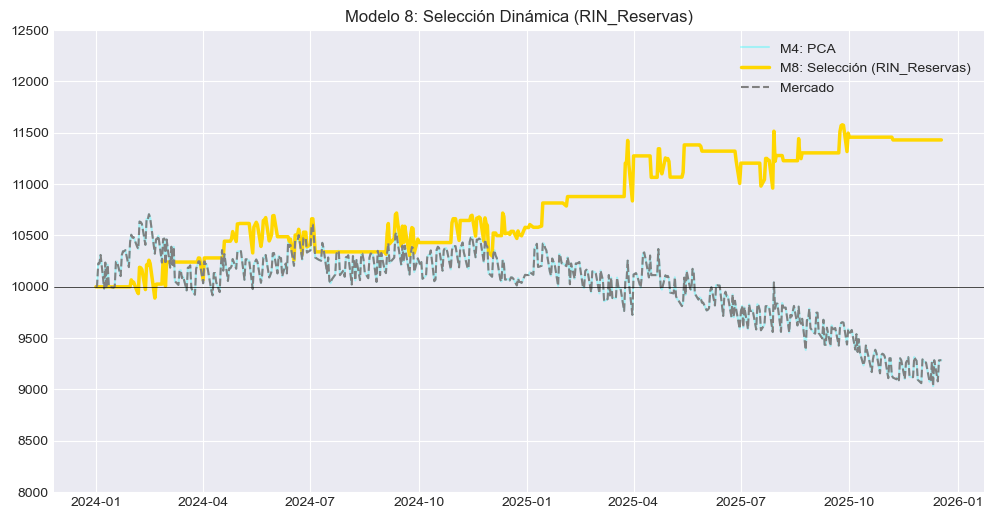

Ganancia Modelo 8: $1430.53


In [23]:
# ==========================================
# MODELO 8 (CORREGIDO): SELECCIÓN UNIVARIANTE (DINÁMICA)
# ==========================================
from sklearn.feature_selection import SelectKBest, mutual_info_regression

print("--- ENTRENANDO MODELO 8: SELECCIÓN (CORREGIDO) ---")

# 1. PREPARACIÓN
candidates = ['Vol_10d', 'RSI', 'Cobre_Futuros', 'DXY_IndiceDolar', 'VIX_Volatilidad', 'RIN_Reservas']
valid_candidates = [c for c in candidates if c in df.columns]

# Target: Retorno futuro
X_sel_train = train[valid_candidates]
y_sel_train = train['Log_Ret'].shift(-1).fillna(0)

# 2. SELECCIÓN
selector = SelectKBest(score_func=mutual_info_regression, k=1)
selector.fit(X_sel_train, y_sel_train)

best_col_idx = selector.get_support(indices=True)[0]
best_feature_name = valid_candidates[best_col_idx]
print(f"🏆 Variable Ganadora: {best_feature_name}")

# 3. ESTRATEGIA DE TRADING (MEJORADA)
# En lugar de usar el valor absoluto (que puede estancarse), usamos la TENDENCIA.
# Calculamos la media móvil de 20 días de la variable ganadora.
test['Best_MA'] = test[best_feature_name].rolling(window=20).mean()

# Calculamos correlación para saber la dirección
corr = train[best_feature_name].corr(train['Log_Ret'])
direction = 1 if corr > 0 else -1

print(f"Correlación: {corr:.2f} (Dirección: {direction})")

test['Signal_Sel'] = 0

# Si la variable está por encima de su propia media de 20 días -> Es una tendencia fuerte
if direction == 1:
    # Relación Positiva: Si sube la variable, compramos
    test.loc[test[best_feature_name] > test['Best_MA'], 'Signal_Sel'] = 1
    test.loc[test[best_feature_name] < test['Best_MA'], 'Signal_Sel'] = -1
else:
    # Relación Negativa (Inversa): Si sube la variable, vendemos
    test.loc[test[best_feature_name] > test['Best_MA'], 'Signal_Sel'] = -1
    test.loc[test[best_feature_name] < test['Best_MA'], 'Signal_Sel'] = 1

# Limpieza de nulos por el rolling
test['Signal_Sel'].fillna(0, inplace=True)

# 4. SIMULACIÓN
capital = 10000
position = 0
equity_sel = []

for i in range(len(test)):
    price = test['TC_Yahoo'].iloc[i]
    sig = test['Signal_Sel'].iloc[i]
    
    if sig == 1 and position == 0:
        shares = capital / price
        capital = 0
        position = 1
    elif sig == -1 and position == 1:
        capital = shares * price
        shares = 0
        position = 0
        
    val = capital + (shares * price if position == 1 else 0)
    equity_sel.append(val)

test['Equity_Sel'] = equity_sel

# 5. GRÁFICO
plt.figure(figsize=(12, 6))

if 'Equity_PCA' in test.columns:
    plt.plot(test['Equity_PCA'], label='M4: PCA', color='cyan', alpha=0.3)

plt.plot(test['Equity_Sel'], label=f'M8: Selección ({best_feature_name})', color='gold', linewidth=2.5)
plt.plot(test['Buy_Hold'], label='Mercado', color='gray', linestyle='--')

plt.ylim(8000, 12500)
plt.axhline(10000, color='black', linewidth=0.5)
plt.title(f"Modelo 8: Selección Dinámica ({best_feature_name})")
plt.legend()
plt.show()

print(f"Ganancia Modelo 8: ${test['Equity_Sel'].iloc[-1] - 10000:.2f}")

In [24]:
# ==========================================
# MODELO 9: ROBUST SCALER + ELLIPTIC ENVELOPE
# Fuente: Cap 3 - Preprocesamiento Robusto
# ==========================================
from sklearn.preprocessing import RobustScaler
from sklearn.covariance import EllipticEnvelope

print("--- ENTRENANDO MODELO 9: ROBUST OUTLIER DETECTION ---")

# 1. ESCALADO ROBUSTO (Ignora Outliers)
r_scaler = RobustScaler()
# Usamos Retorno y Volatilidad
X_rob_train = r_scaler.fit_transform(train[['Log_Ret', 'Vol_10d']])
X_rob_test = r_scaler.transform(test[['Log_Ret', 'Vol_10d']])

# 2. DETECCIÓN DE OUTLIERS GAUSSIANOS
# Asumimos que el mercado es normal, pero tiene eventos raros (contaminación 10%)
ee = EllipticEnvelope(contamination=0.1, random_state=42)
ee.fit(X_rob_train)

# Predicción: 1 (Normal/Inlier), -1 (Anomalía/Outlier)
test['Signal_Rob'] = ee.predict(X_rob_test)

# Estrategia: Solo operamos (Comprar) si el mercado es "Normal" (1).
# Si es Outlier (-1), nos salimos (0/Vender).
# Convertimos el -1 a señal de venta
test['Signal_Rob'] = np.where(test['Signal_Rob'] == -1, -1, 1)

# 3. BACKTESTING
capital = 10000
position = 0
equity_rob = []

for i in range(len(test)):
    price = test['TC_Yahoo'].iloc[i]
    sig = test['Signal_Rob'].iloc[i]
    
    if sig == 1 and position == 0:
        shares = capital / price
        capital = 0
        position = 1
    elif sig == -1 and position == 1:
        capital = shares * price
        shares = 0
        position = 0
    
    val = capital + (shares * price if position == 1 else 0)
    equity_rob.append(val)

test['Equity_Rob'] = equity_rob
print(f"Ganancia Modelo 9: ${test['Equity_Rob'].iloc[-1] - 10000:.2f}")


# ==========================================
# MODELO 10: CARACTERÍSTICAS POLINÓMICAS (INTERACCIONES)
# Fuente: Cap 3 - Ingeniería de Características
# ==========================================
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

print("--- ENTRENANDO MODELO 10: POLINOMIAL ---")

# 1. CREAR INTERACCIONES
# ¿Importa el Cobre? Sí. ¿Importa el VIX? Sí.
# ¿Importa (Cobre * VIX)? ¡Probablemente más! (Crisis con Cobre bajo)
poly = PolynomialFeatures(degree=2, include_bias=False)
vars_poly = ['Cobre_Futuros', 'VIX_Volatilidad'] 
# Verificamos que existan
vars_poly = [v for v in vars_poly if v in df.columns]

if vars_poly:
    X_poly_train = poly.fit_transform(train[vars_poly])
    X_poly_test = poly.transform(test[vars_poly])
    
    # Target: Retorno mañana
    y_poly_train = train['Log_Ret'].shift(-1).fillna(0)

    # 2. REGRESIÓN RIDGE (Para manejar la complejidad)
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_poly_train, y_poly_train)

    # 3. PREDICCIÓN
    preds_poly = ridge.predict(X_poly_test)
    
    # Estrategia: Si predice retorno positivo -> Comprar
    test['Signal_Poly'] = np.where(preds_poly > 0, 1, -1)

    # 4. BACKTESTING
    capital = 10000
    position = 0
    equity_poly = []

    for i in range(len(test)):
        price = test['TC_Yahoo'].iloc[i]
        sig = test['Signal_Poly'].iloc[i]
        
        if sig == 1 and position == 0:
            shares = capital / price
            capital = 0
            position = 1
        elif sig == -1 and position == 1:
            capital = shares * price
            shares = 0
            position = 0
        
        val = capital + (shares * price if position == 1 else 0)
        equity_poly.append(val)

    test['Equity_Poly'] = equity_poly
    print(f"Ganancia Modelo 10: ${test['Equity_Poly'].iloc[-1] - 10000:.2f}")

else:
    print("⚠️ Faltan variables para el Modelo 10.")
    test['Equity_Poly'] = test['Buy_Hold'] # Fallback

--- ENTRENANDO MODELO 9: ROBUST OUTLIER DETECTION ---
Ganancia Modelo 9: $-3624.95
--- ENTRENANDO MODELO 10: POLINOMIAL ---
Ganancia Modelo 10: $431.44


--- ENTRENANDO MODELO 9 ---


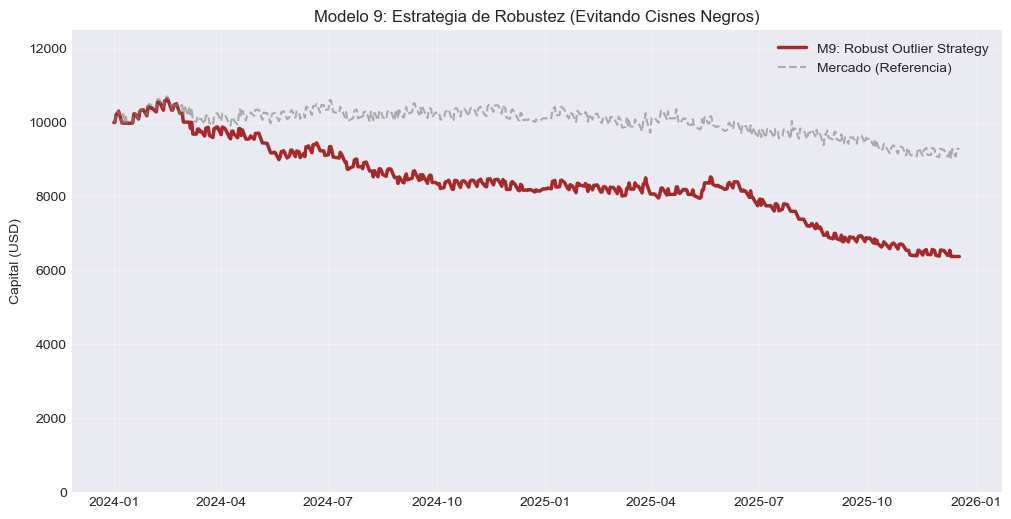

Ganancia Final Modelo 9: $-3624.95


In [28]:
# ==========================================
# MODELO 9: PREPROCESAMIENTO ROBUSTO + DETECCIÓN DE OUTLIERS
# ==========================================
from sklearn.preprocessing import RobustScaler
from sklearn.covariance import EllipticEnvelope

print("--- ENTRENANDO MODELO 9 ---")

# 1. ESCALADO ROBUSTO (Ignora eventos extremos)
# Usamos Retorno y Volatilidad, que suelen tener picos locos
r_scaler = RobustScaler()
X_rob_train = r_scaler.fit_transform(train[['Log_Ret', 'Vol_10d']])
X_rob_test = r_scaler.transform(test[['Log_Ret', 'Vol_10d']])

# 2. DETECTOR DE "CISNES NEGROS" (Elliptic Envelope)
# Asumimos una contaminación del 10% (días muy raros)
ee = EllipticEnvelope(contamination=0.1, random_state=42)
ee.fit(X_rob_train)

# Predicción: 1 = Normal (Operar), -1 = Anomalía (Salirse)
test['Signal_Rob'] = ee.predict(X_rob_test)

# 3. ESTRATEGIA: FILTRO DE CALIDAD
# Si el mercado es "Normal" (1) -> Compramos (Apostamos a la tendencia)
# Si es "Anomalía" (-1) -> Vendemos (Nos protegemos en Cash)
# Ajustamos la señal para el loop de trading (-1 para venta, 1 para compra)
test['Signal_Rob'] = np.where(test['Signal_Rob'] == -1, -1, 1)

# 4. SIMULACIÓN DE TRADING
capital = 10000
position = 0
equity_rob = []

for i in range(len(test)):
    price = test['TC_Yahoo'].iloc[i]
    sig = test['Signal_Rob'].iloc[i]
    
    if sig == 1 and position == 0:
        shares = capital / price
        capital = 0
        position = 1
    elif sig == -1 and position == 1:
        capital = shares * price
        shares = 0
        position = 0
    
    val = capital + (shares * price if position == 1 else 0)
    equity_rob.append(val)

test['Equity_Rob'] = equity_rob

# 5. GRÁFICO EXCLUSIVO MODELO 9
plt.figure(figsize=(12, 6))
plt.plot(test['Equity_Rob'], label='M9: Robust Outlier Strategy', color='brown', linewidth=2.5)
plt.plot(test['Buy_Hold'], label='Mercado (Referencia)', color='gray', linestyle='--', alpha=0.6)

plt.title("Modelo 9: Estrategia de Robustez (Evitando Cisnes Negros)")
plt.ylabel("Capital (USD)")
plt.legend()
plt.ylim(0, 12500) # Ajuste de escala
plt.grid(True, alpha=0.3)
plt.show()

print(f"Ganancia Final Modelo 9: ${test['Equity_Rob'].iloc[-1] - 10000:.2f}")

--- ENTRENANDO MODELO 10 ---


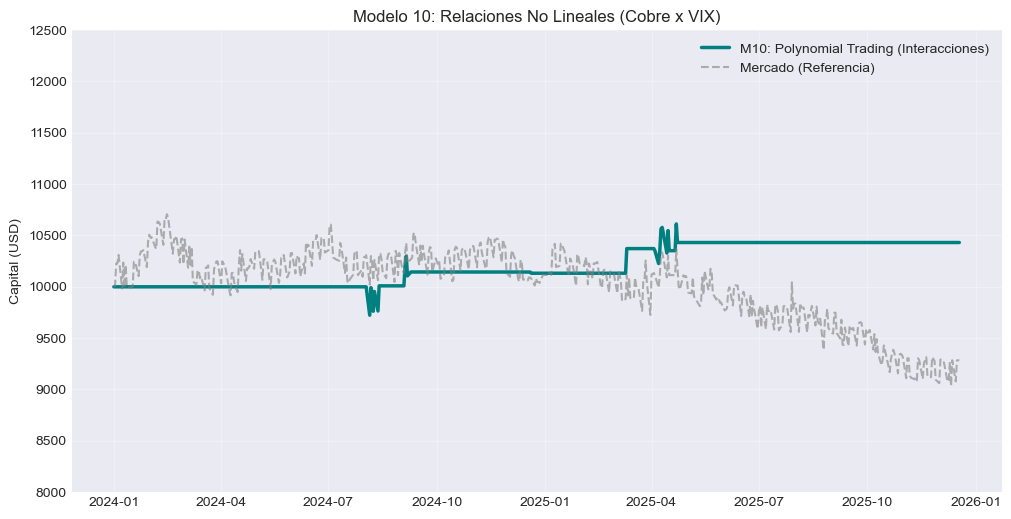

Ganancia Final Modelo 10: $431.44


In [29]:
# ==========================================
# MODELO 10: CARACTERÍSTICAS POLINÓMICAS (INTERACCIONES NO LINEALES)
# ==========================================
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

print("--- ENTRENANDO MODELO 10 ---")

# 1. SELECCIÓN DE VARIABLES PARA INTERACTUAR
# Usamos Cobre y VIX porque su combinación suele predecir crisis
vars_poly = ['Cobre_Futuros', 'VIX_Volatilidad'] 
vars_poly = [v for v in vars_poly if v in df.columns]

if vars_poly:
    # 2. TRANSFORMACIÓN POLINÓMICA
    # degree=2 crea: [Cobre, VIX, Cobre^2, VIX^2, Cobre*VIX]
    poly = PolynomialFeatures(degree=2, include_bias=False)
    
    X_poly_train = poly.fit_transform(train[vars_poly])
    X_poly_test = poly.transform(test[vars_poly])
    
    # Target: Predecir el retorno de MAÑANA
    y_poly_train = train['Log_Ret'].shift(-1).fillna(0)

    # 3. MODELO PREDICTOR (Ridge Regression)
    # Ridge es mejor que LinearRegression aquí porque maneja la multicolinealidad
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_poly_train, y_poly_train)

    # 4. PREDICCIÓN Y SEÑALES
    preds_poly = ridge.predict(X_poly_test)
    
    # Si predice que mañana sube (>0) -> Comprar (1)
    # Si predice que mañana baja (<=0) -> Vender (-1)
    test['Signal_Poly'] = np.where(preds_poly > 0, 1, -1)

    # 5. SIMULACIÓN DE TRADING
    capital = 10000
    position = 0
    equity_poly = []

    for i in range(len(test)):
        price = test['TC_Yahoo'].iloc[i]
        sig = test['Signal_Poly'].iloc[i]
        
        if sig == 1 and position == 0:
            shares = capital / price
            capital = 0
            position = 1
        elif sig == -1 and position == 1:
            capital = shares * price
            shares = 0
            position = 0
        
        val = capital + (shares * price if position == 1 else 0)
        equity_poly.append(val)

    test['Equity_Poly'] = equity_poly

    # 6. GRÁFICO EXCLUSIVO MODELO 10
    plt.figure(figsize=(12, 6))
    plt.plot(test['Equity_Poly'], label='M10: Polynomial Trading (Interacciones)', color='teal', linewidth=2.5)
    plt.plot(test['Buy_Hold'], label='Mercado (Referencia)', color='gray', linestyle='--', alpha=0.6)

    plt.title("Modelo 10: Relaciones No Lineales (Cobre x VIX)")
    plt.ylabel("Capital (USD)")
    plt.legend()
    plt.ylim(8000, 12500) # Ajuste de escala
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Ganancia Final Modelo 10: ${test['Equity_Poly'].iloc[-1] - 10000:.2f}")

else:
    print("⚠️ No se encontraron las variables Cobre y VIX en el dataset.")

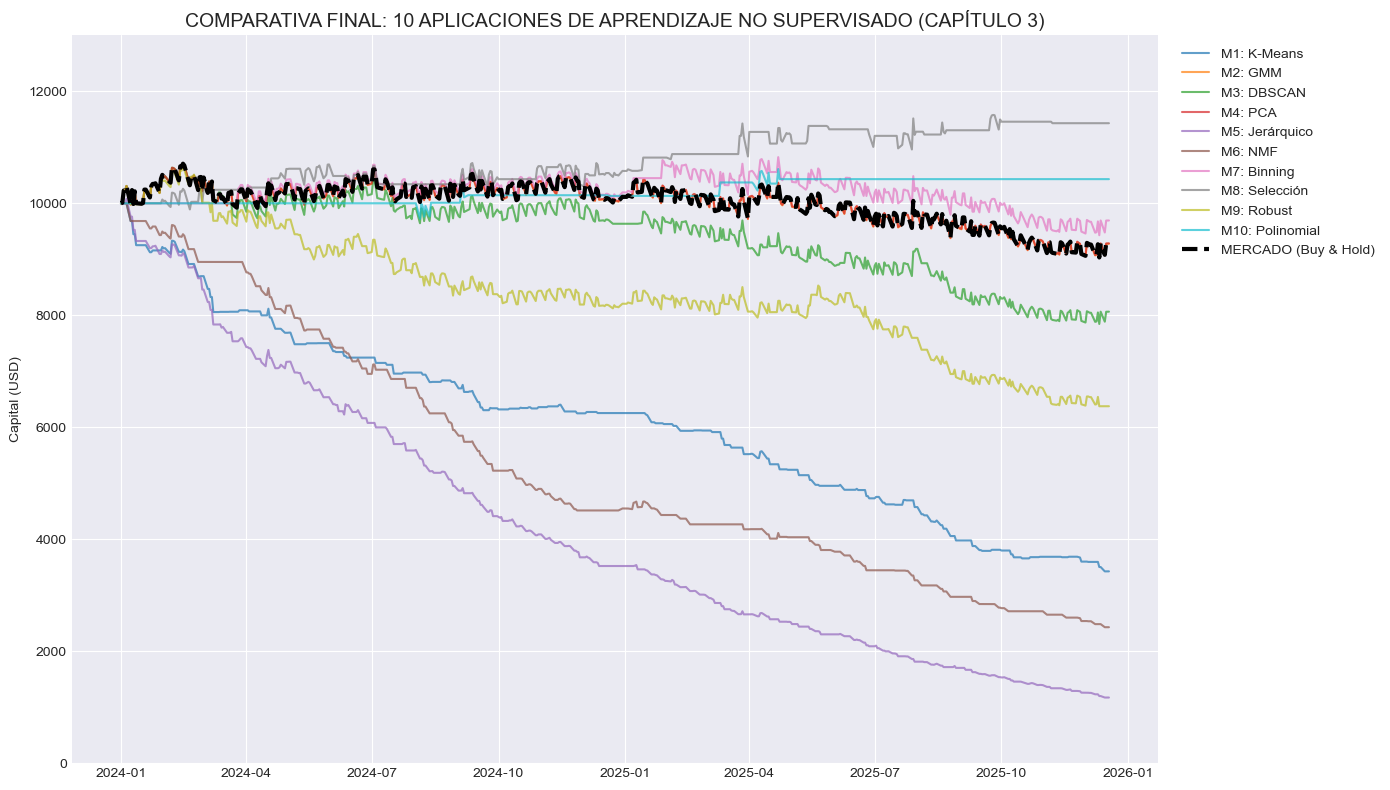


RANKING FINAL:
            Modelo         Final     Ganancia
7    M8: Selección  11430.529502  1430.529502
9  M10: Polinomial  10431.436682   431.436682
6      M7: Binning   9693.176094  -306.823906
3          M4: PCA   9284.823455  -715.176545
1          M2: GMM   9276.425328  -723.574672
2       M3: DBSCAN   8063.969984 -1936.030016
8       M9: Robust   6375.052301 -3624.947699
0      M1: K-Means   3425.779322 -6574.220678
5          M6: NMF   2427.979557 -7572.020443
4   M5: Jerárquico   1171.888822 -8828.111178


In [26]:
# ==========================================
# RESUMEN FINAL: LOS 10 MODELOS
# ==========================================
plt.figure(figsize=(14, 8))

# Lista de tus modelos
models = {
    'M1: K-Means': 'Equity_KMeans',
    'M2: GMM': 'Equity_GMM',
    'M3: DBSCAN': 'Equity_DBSCAN',
    'M4: PCA': 'Equity_PCA',
    'M5: Jerárquico': 'Equity_HC',
    'M6: NMF': 'Equity_NMF',
    'M7: Binning': 'Equity_Bin',
    'M8: Selección': 'Equity_Sel',
    'M9: Robust': 'Equity_Rob',
    'M10: Polinomial': 'Equity_Poly'
}

# Graficar
for name, col in models.items():
    if col in test.columns:
        # Destacar los mejores (opcional: personaliza colores)
        plt.plot(test[col], label=name, alpha=0.7, linewidth=1.5)

# Mercado
plt.plot(test['Buy_Hold'], label='MERCADO (Buy & Hold)', color='black', linewidth=3, linestyle='--')

plt.title("COMPARATIVA FINAL: 10 APLICACIONES DE APRENDIZAJE NO SUPERVISADO (CAPÍTULO 3)", fontsize=14)
plt.ylabel("Capital (USD)")
plt.ylim(0, 13000)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# TABLA DE RESULTADOS
results = []
for name, col in models.items():
    if col in test.columns:
        final_val = test[col].iloc[-1]
        profit = final_val - 10000
        results.append({'Modelo': name, 'Final': final_val, 'Ganancia': profit})

results_df = pd.DataFrame(results).sort_values('Ganancia', ascending=False)
print("\nRANKING FINAL:")
print(results_df)